In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'serif'

from joblib import Parallel, delayed

from scipy.special import iv

import pickle

import schwingerModel as sim

In [2]:
with open('configs/strongCoupling.pkl', 'rb') as f:
    temp = pickle.load(f)

In [3]:
m = temp.fMass
a = temp.a
dimx = temp.dimx
dimt = temp.dimt
beta = temp.beta
totalSteps = temp.metroSteps

print(m)
print(a)
print(dimx)
print(dimt)
print(beta)
print(totalSteps)

0.1
1
8
16
1
50000


In [10]:
bIn = 0
skp = 10

thetas = np.linspace(0,np.pi*.5,20)

correls = []
masses = []

for t in thetas:
    c = sim.distillation.correlStats(temp,burnIn=bIn,autocorrSkip=skp,theta=t)
    correls.append(c)
    masses.append(sim.distillation.correlMassExtract(c,fitT=[3,11],diagCov=True))

masses=np.array(masses)

configs:   0%|          | 0/5000 [00:00<?, ?it/s]

configs:   0%|          | 0/5000 [00:00<?, ?it/s]

configs:   0%|          | 0/5000 [00:00<?, ?it/s]

configs:   0%|          | 0/5000 [00:00<?, ?it/s]

configs:   0%|          | 0/5000 [00:00<?, ?it/s]

...

configs:   0%|          | 0/5000 [00:00<?, ?it/s]

configs:   0%|          | 0/5000 [00:00<?, ?it/s]

configs:   0%|          | 0/5000 [00:00<?, ?it/s]

configs:   0%|          | 0/5000 [00:00<?, ?it/s]

configs:   0%|          | 0/5000 [00:00<?, ?it/s]

Text(0.5, 1.0, 'Correlation: $N_t = 16$, $N_x=8$, $a=1$, $m=0.1$, $\\beta=1$')

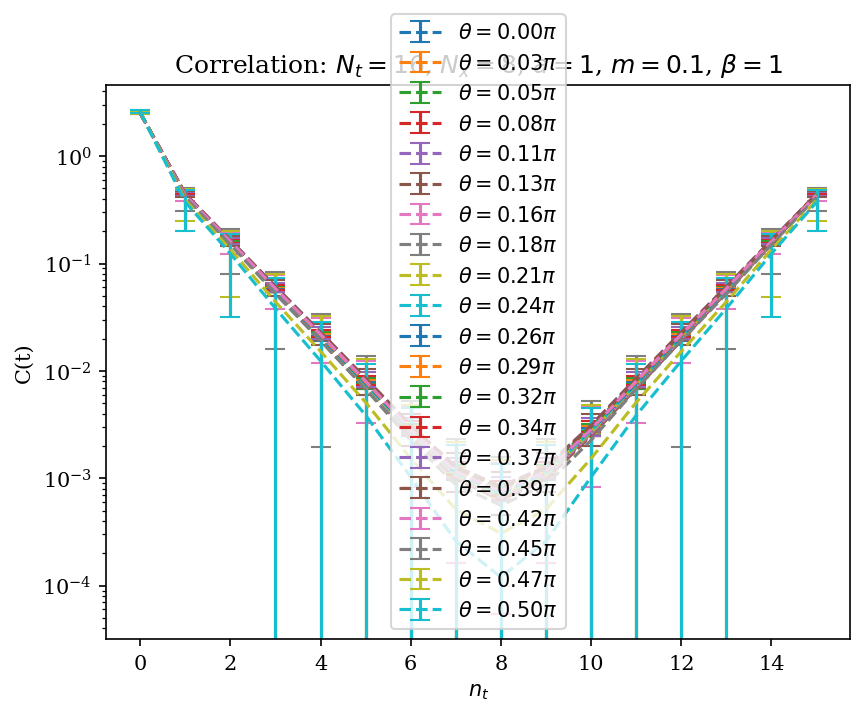

In [11]:
plt.figure(dpi=150)
for i, c in enumerate(correls):
    plt.errorbar(x=np.arange(len(c[0])), y=c[0],yerr=np.abs(c[1]),label=rf"$\theta={(thetas[i]/np.pi):.2f} \pi$",ls="--",capsize=5)
    
plt.semilogy()
plt.legend()
plt.xlabel("$n_t$")
plt.ylabel("C(t)")
plt.title(rf"Correlation: $N_t = {dimt}$, $N_x={dimx}$, $a={a}$, $m={m}$, $\beta={beta}$")

Text(0.5, 1.0, '$m_\\text{ps}$ vs. $\\theta$: $N_t = 16$, $N_x=8$, $a=1$, $m=0.1$, $\\beta=1$')

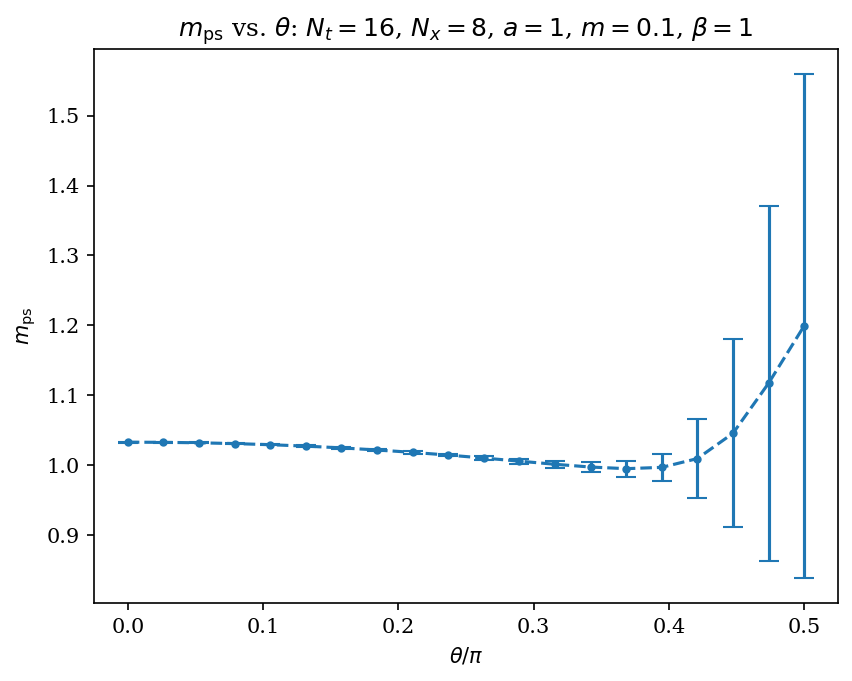

In [16]:
plt.figure(dpi=150)
plt.errorbar(x=thetas/np.pi, y=masses[:,0],yerr=masses[:,1],ls="--",capsize=5,marker=".")

plt.xlabel(r"$\theta/\pi$")
plt.ylabel(r"$m_\text{ps}$")
plt.title(rf"$m_\text{{ps}}$ vs. $\theta$: $N_t = {dimt}$, $N_x={dimx}$, $a={a}$, $m={m}$, $\beta={beta}$")